In [ ]:
import torch
import librosa
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [30]:
import pandas as pd
df_test = pd.read_csv("fma_mapping.csv")
df_test.head()

,track_id,genre,path,label
0,2,Hip-Hop,C:\Users\PC\Desktop\eksploracje\fma_small\000\...,3
1,5,Hip-Hop,C:\Users\PC\Desktop\eksploracje\fma_small\000\...,3
2,10,Pop,C:\Users\PC\Desktop\eksploracje\fma_small\000\...,6
3,140,Folk,C:\Users\PC\Desktop\eksploracje\fma_small\000\...,2
4,141,Folk,C:\Users\PC\Desktop\eksploracje\fma_small\000\...,2


In [3]:
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor

model = AutoModelForAudioClassification.from_pretrained("./finalny_model_muzyczny")
feature_extractor = AutoFeatureExtractor.from_pretrained("./finalny_model_muzyczny")

print("Model załadowany pomyślnie")

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

Model załadowany pomyślnie


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

HubertForSequenceClassification(
  (hubert): HubertModel(
    (feature_extractor): HubertFeatureEncoder(
      (conv_layers): ModuleList(
        (0): HubertGroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x HubertNoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x HubertNoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): HubertFeatureProjection(
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): HubertEncoder(
      (pos_conv_embed): HubertPositionalConvEmbedding(

In [27]:
def predict_genre(audio_path):
    y, sr = librosa.load(audio_path, sr=16000, duration=10)
    inputs = feature_extractor(y, sampling_rate=16000, return_tensors="pt").to(device)
    
    with torch.no_grad():
        logits = model(**inputs).logits
    probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
    
    results = {}
    for i, prob in enumerate(probabilities):
        genre = model.config.id2label[i]
        results[genre] = round(prob.item(), 3)
    
    sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
    
    plt.figure(figsize=(10, 4))
    sns.barplot(x=list(sorted_results.values()), y=list(sorted_results.keys()), color='#5a42f5')
    file_name = os.path.basename(audio_path)
    plt.title(f"Predykcja dla: {file_name}")
    plt.xlabel("Prawdopodobieństwo")
    plt.grid(True)
    plt.show()

    return sorted_results

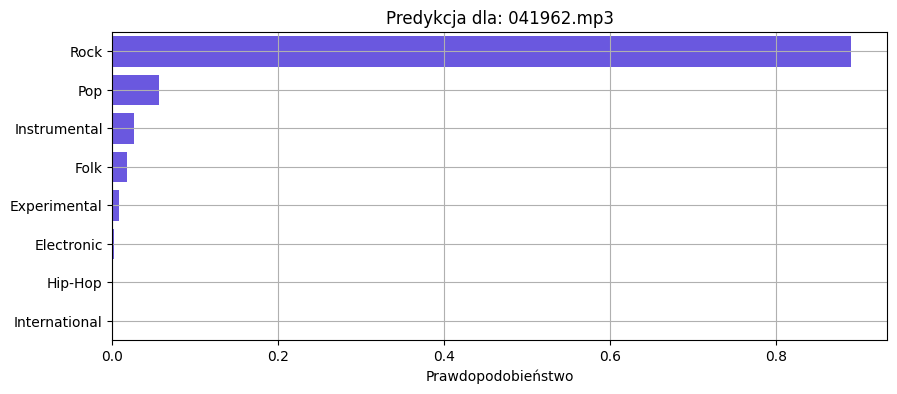

Rzeczywistość: Rock
Predykcja: Rock (0.89)


In [29]:
test_path = r"C:\Users\PC\Desktop\eksploracje\fma_small\041\041962.mp3"
filename = os.path.basename(test_path)
track_id = int(filename.split('.')[0])

predictions = predict_genre(test_path)

true_genre = df_test[df_test['track_id'] == track_id]['genre'].values[0]
top_prediction = list(predictions.keys())[0]
confidence = predictions[top_prediction]
print(f"Rzeczywistość: {true_genre}")
print(f"Predykcja: {top_prediction} ({confidence})")